# Workshop 2: Clasificación - Detección de Fatiga Muscular en Ciclismo

## Problema
Detectar si un ciclista está en condición normal o si tiene desgaste muscular (fatiga) a partir de señales de electromiografía (EMG) de 8 músculos de la pierna.

## Dataset
- Fuente: HuggingFace - Muscle_Fatigue_Cycling
- 8 señales de músculos (canales EMG)
- Frecuencia de muestreo: 1000 Hz
- Target: Estado muscular (0=normal, 1=desgaste, 2=desgaste → se convierte a 1)

## Estrategia
1. Cargar y explorar datos crudos
2. Crear características desde las señales usando ventanas de 1 segundo
3. Hacer análisis exploratorio detallado
4. Entrenar 5 modelos diferentes y comparar
5. Seleccionar el mejor y evaluar en test
6. Probar con datos artificiales

## 1. Análisis Preliminar del Dataset
Cargamos el dataset y exploraremos su estructura básica.

In [2]:
# Importar todas las librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import welch
from scipy.fft import fft, fftfreq
import warnings
warnings.filterwarnings('ignore')

# Para Machine Learning
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

# Para redes neuronales
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Cargar directamente el dataset desde HuggingFace
from datasets import load_dataset

print("✓ Librerías importadas exitosamente")


✓ Librerías importadas exitosamente


In [3]:
# Cargar el dataset desde HuggingFace
# Este dataset contiene señales EMG de 8 músculos registradas a 1000 Hz
print("Cargando dataset...")
dataset = load_dataset("YominE/Muscle_Fatigue_Cycling")
df = pd.DataFrame(dataset['train'])

print(f"✓ Dataset cargado: {df.shape[0]} muestras, {df.shape[1]} columnas")
print(f"\nPrimeras filas:")
print(df.head())

print(f"\nInfo del dataset:")
print(df.info())

print(f"\nNombres de columnas:")
print(df.columns.tolist())


Cargando dataset...


README.md: 0.00B [00:00, ?B/s]

Patient1.csv:   0%|          | 0.00/114M [00:00<?, ?B/s]

Patient2.csv:   0%|          | 0.00/290M [00:00<?, ?B/s]

Patient3.csv:   0%|          | 0.00/95.1M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3002137 [00:00<?, ? examples/s]

✓ Dataset cargado: 3002137 muestras, 10 columnas

Primeras filas:
    Time  Right Rectus femoris  Left Gluteus maximus  \
0  0.000             -0.000264             -0.000015   
1  0.001             -0.001002             -0.000045   
2  0.002             -0.002173             -0.000034   
3  0.003             -0.002676              0.000185   
4  0.004             -0.000844              0.000785   

   Left Gastrocnemius medialis  Left Semitendinosus  \
0                     0.000344             0.000108   
1                     0.001342             0.000429   
2                     0.002944             0.001133   
3                     0.003504             0.002319   
4                     0.000426             0.003950   

   Left Biceps femoris caput longus  Right Vastus medialis  \
0                          0.000182               0.000401   
1                          0.000712               0.002234   
2                          0.001692               0.007634   
3                 

In [11]:
# Preprocesar el target: convertir a problema binario
# La instrucción dice: cambiar etiqueta 2 por 1
print(f"Valores únicos del target antes: {sorted(df['Target'].unique())}")
print(f"Frecuencia antes:\n{df['Target'].value_counts().sort_index()}")

# Convertir etiqueta 2 a 1 (ambas representan desgaste muscular)
df['Target'] = df['Target'].replace(2, 1)

print(f"\nValores únicos del target después: {sorted(df['Target'].unique())}")
print(f"Frecuencia después:")
print(df['Target'].value_counts().sort_index())

print("\n=== INTERPRETACIÓN ===")
print("0 = Condición normal (músculo sin fatiga)")
print("1 = Desgaste muscular (el músculo está fatigado)")
print(f"Balance de clases: {df['Target'].value_counts()[0]} normales, {df['Target'].value_counts()[1]} fatigados")

Valores únicos del target antes: [np.int64(0), np.int64(1)]
Frecuencia antes:
Target
0    2127600
1     874537
Name: count, dtype: int64

Valores únicos del target después: [np.int64(0), np.int64(1)]
Frecuencia después:
Target
0    2127600
1     874537
Name: count, dtype: int64

=== INTERPRETACIÓN ===
0 = Condición normal (músculo sin fatiga)
1 = Desgaste muscular (el músculo está fatigado)
Balance de clases: 2127600 normales, 874537 fatigados


## 2. Exploración y Visualización de Señales EMG

Veamos cómo se ven las señales crudas en el tiempo. Esto nos ayuda a entender qué estamos midiendo.

Canales EMG encontrados: ['Right Rectus femoris', 'Left Gluteus maximus', 'Left Gastrocnemius medialis', 'Left Semitendinosus', 'Left Biceps femoris caput longus', 'Right Vastus medialis', 'Right Tibialis anterior', 'Left Gastrocnemius lateralis']


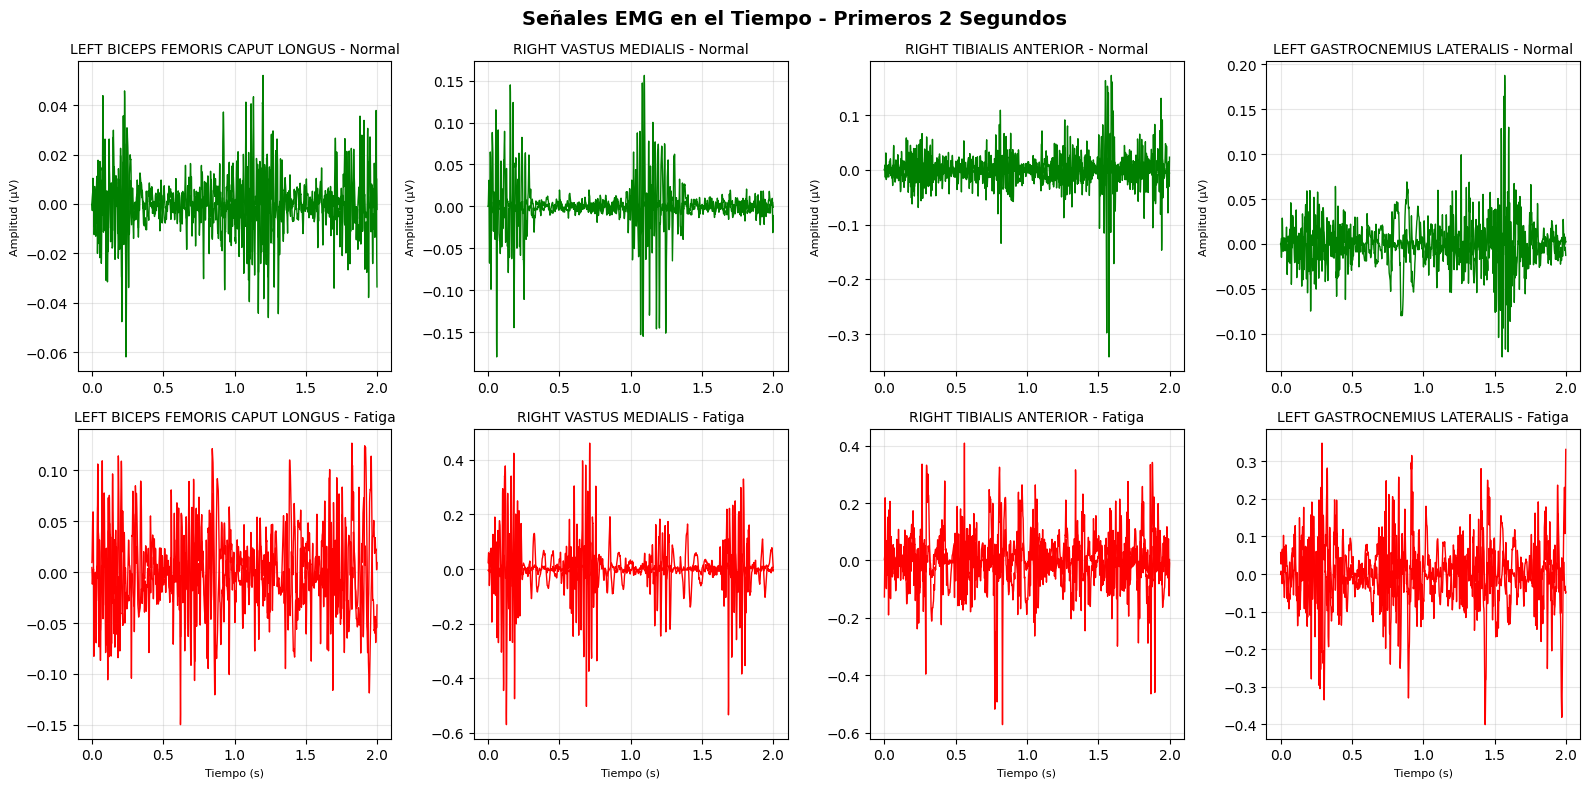


=== INTERPRETACIÓN VISUAL ===
FILA 1 (Verde): Señal de un ciclista en condición NORMAL
FILA 2 (Rojo): Señal de un ciclista con FATIGA MUSCULAR

Observaciones:
- Las amplitudes pueden variar entre canales (cada músculo tiene diferente intensidad)
- La fatiga puede cambiar la forma y frecuencia de las oscilaciones
- Hay ruido en las señales: variaciones rápidas y pequeñas
- Las señales no son periódicas, reflejan la actividad muscular real


In [15]:
# Identificar las columnas de los 8 músculos
# El dataset tiene 8 canales EMG etiquetados como emg_1, emg_2, ..., emg_8
# The actual muscle column names are now full names as identified in the previous cell's context.
muscle_columns = ['Right Rectus femoris', 'Left Gluteus maximus', 'Left Gastrocnemius medialis',
                  'Left Semitendinosus', 'Left Biceps femoris caput longus', 'Right Vastus medialis',
                  'Right Tibialis anterior', 'Left Gastrocnemius lateralis']
print(f"Canales EMG encontrados: {muscle_columns}")

# Frecuencia de muestreo: 1000 Hz significa 1000 muestras por segundo
fs = 1000
# Veamos los primeros 2 segundos (2000 muestras) de una muestra
n_samples_to_plot = 2000  # 2 segundos
time_axis = np.arange(n_samples_to_plot) / fs

# Crear visualización: mostramos una muestra normal y otra fatigada
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Señales EMG en el Tiempo - Primeros 2 Segundos', fontsize=14, fontweight='bold')

# Muestra 1: Condición normal (target = 0)
# Find the first index where Target is 0 and extract a segment of n_samples_to_plot
first_normal_index = df[df['Target'] == 0].index[0]
normal_segment_emg = df.loc[first_normal_index : first_normal_index + n_samples_to_plot - 1, muscle_columns].values

# Muestra 2: Condición con fatiga (target = 1)
# Find the first index where Target is 1 and extract a segment of n_samples_to_plot
first_fatigue_index = df[df['Target'] == 1].index[0]
fatigue_segment_emg = df.loc[first_fatigue_index : first_fatigue_index + n_samples_to_plot - 1, muscle_columns].values

for i, muscle in enumerate(muscle_columns):
    row = i // 4
    col = i % 4

    # Graficar condición normal
    axes[0, col].plot(time_axis, normal_segment_emg[:, i], color='green', linewidth=1)
    axes[0, col].set_title(f'{muscle.upper()} - Normal', fontsize=10)
    axes[0, col].set_ylabel('Amplitud (μV)', fontsize=8)
    axes[0, col].grid(True, alpha=0.3)

    # Graficar condición con fatiga
    axes[1, col].plot(time_axis, fatigue_segment_emg[:, i], color='red', linewidth=1)
    axes[1, col].set_title(f'{muscle.upper()} - Fatiga', fontsize=10)
    axes[1, col].set_xlabel('Tiempo (s)', fontsize=8)
    axes[1, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n=== INTERPRETACIÓN VISUAL ===")
print("FILA 1 (Verde): Señal de un ciclista en condición NORMAL")
print("FILA 2 (Rojo): Señal de un ciclista con FATIGA MUSCULAR")
print("\nObservaciones:")
print("- Las amplitudes pueden variar entre canales (cada músculo tiene diferente intensidad)")
print("- La fatiga puede cambiar la forma y frecuencia de las oscilaciones")
print("- Hay ruido en las señales: variaciones rápidas y pequeñas")
print("- Las señales no son periódicas, reflejan la actividad muscular real")

## 3. Extracción de Características (Feature Engineering)

Transformamos las señales crudas en características que resumen la información de cada segundo.

**¿Por qué hacemos esto?**
- Las señales crudas tienen 1000+ muestras por segundo (muy grande)
- La fatiga se ve a nivel de SEGUNDOS, no de milisegundos
- Extraemos características que capturan: energía, variabilidad, contenido frecuencial
- El resultado es una tabla pequeña y manejable para entrenar modelos

In [18]:
def extraer_caracteristicas(ventana, fs=1000):
    """
    Extrae características del tiempo y frecuencia de una ventana de 1 segundo.

    Parámetros:
    - ventana: array de 1000 muestras (1 segundo)
    - fs: frecuencia de muestreo (1000 Hz)

    Retorna:
    - Lista con 7 características
    """

    # ====== DOMINIO DEL TIEMPO ======
    # 1. RMS (Root Mean Square): energía de la señal
    rms = np.sqrt(np.mean(ventana**2))

    # 2. Varianza: cuánta dispersión hay en los valores
    varianza = np.var(ventana)

    # 3. ZCR (Zero Crossing Rate): cuántas veces cruza por cero
    zcr = np.sum(np.diff(np.sign(ventana)) != 0)

    # 4. MAV (Mean Absolute Value): promedio del valor absoluto
    mav = np.mean(np.abs(ventana))

    # ====== DOMINIO DE LA FRECUENCIA ======
    # Transformada de Fourier mediante Welch (más robusta que FFT pura)
    freqs, psd = welch(ventana, fs=fs)

    # 5. Potencia Total: energía en el espectro de frecuencias
    potencia_total = np.sum(psd)

    # 6. Frecuencia Media: promedio ponderado de las frecuencias
    frecuencia_media = np.sum(freqs * psd) / np.sum(psd) if np.sum(psd) > 0 else 0

    # 7. Frecuencia Mediana (MDF): frecuencia que divide la potencia en dos mitades
    potencia_acumulada = np.cumsum(psd)
    idx_mediana = np.searchsorted(potencia_acumulada, potencia_acumulada[-1] / 2)
    frecuencia_mediana = freqs[idx_mediana] if idx_mediana < len(freqs) else 0

    return [rms, varianza, zcr, mav, potencia_total, frecuencia_media, frecuencia_mediana]

# Ahora construimos el nuevo dataset con características
print("=" * 60)
print("EXTRAYENDO CARACTERÍSTICAS DE VENTANAS DE 1 SEGUNDO")
print("=" * 60)

fs = 1000
tamanio_ventana = fs  # 1 segundo = 1000 muestras
n_ventanas = len(df) // tamanio_ventana

print(f"\nTotal de muestras: {len(df)}")
print(f"Tamaño de ventana: {tamanio_ventana} muestras (1 segundo)")
print(f"Número de ventanas: {n_ventanas}")

# Construir el nuevo dataset
filas = []

for idx_ventana in range(n_ventanas):
    inicio = idx_ventana * tamanio_ventana
    fin = inicio + tamanio_ventana

    ventana_df = df.iloc[inicio:fin]
    fila = {}

    # Para cada músculo, extraer características
    for muscle in muscle_columns:
        ventana_senal = ventana_df[muscle].values
        caracteristicas = extraer_caracteristicas(ventana_senal, fs=fs)

        # Guardar cada característica con su nombre
        nombres_feat = ['rms', 'var', 'zcr', 'mav', 'potencia', 'freq_media', 'freq_mediana']
        for nombre, valor in zip(nombres_feat, caracteristicas):
            fila[f'{muscle}_{nombre}'] = valor

    # El target de la ventana es el más frecuente en esas 1000 muestras
    target_ventana = ventana_df['Target'].mode()[0]
    fila['target'] = target_ventana

    filas.append(fila)

# Crear DataFrame con las nuevas características
df_features = pd.DataFrame(filas)

print(f"\n✓ Dataset de características creado!")
print(f"Forma nueva: {df_features.shape[0]} ventanas × {df_features.shape[1]} columnas")
print(f"\nPrimeras filas del nuevo dataset:")
print(df_features.head())

# Verificar balance
print(f"\nBalance de clases en el nuevo dataset:")
print(df_features['target'].value_counts())

EXTRAYENDO CARACTERÍSTICAS DE VENTANAS DE 1 SEGUNDO

Total de muestras: 3002137
Tamaño de ventana: 1000 muestras (1 segundo)
Número de ventanas: 3002

✓ Dataset de características creado!
Forma nueva: 3002 ventanas × 57 columnas

Primeras filas del nuevo dataset:
   Right Rectus femoris_rms  Right Rectus femoris_var  \
0                  0.011706                  0.000137   
1                  0.014023                  0.000197   
2                  0.014820                  0.000220   
3                  0.013817                  0.000191   
4                  0.013326                  0.000177   

   Right Rectus femoris_zcr  Right Rectus femoris_mav  \
0                       123                  0.008125   
1                       111                  0.010118   
2                       121                  0.010151   
3                       121                  0.009894   
4                       122                  0.009676   

   Right Rectus femoris_potencia  Right Rectus fem

## 4. Análisis Exploratorio de Datos (EDA)

Exploraremos el nuevo dataset de características para entender patrones y relaciones.

ESTADÍSTICOS DESCRIPTIVOS
       Right Rectus femoris_rms  Right Rectus femoris_var  \
count               3002.000000               3002.000000   
mean                   0.035700                  0.001869   
std                    0.024379                  0.003613   
min                    0.002970                  0.000009   
25%                    0.021569                  0.000465   
50%                    0.029745                  0.000885   
75%                    0.042171                  0.001778   
max                    0.190683                  0.036360   

       Right Rectus femoris_zcr  Right Rectus femoris_mav  \
count               3002.000000               3002.000000   
mean                 108.874084                  0.022596   
std                   13.094489                  0.015262   
min                   63.000000                  0.002243   
25%                  100.000000                  0.013461   
50%                  109.000000                  0.018516 

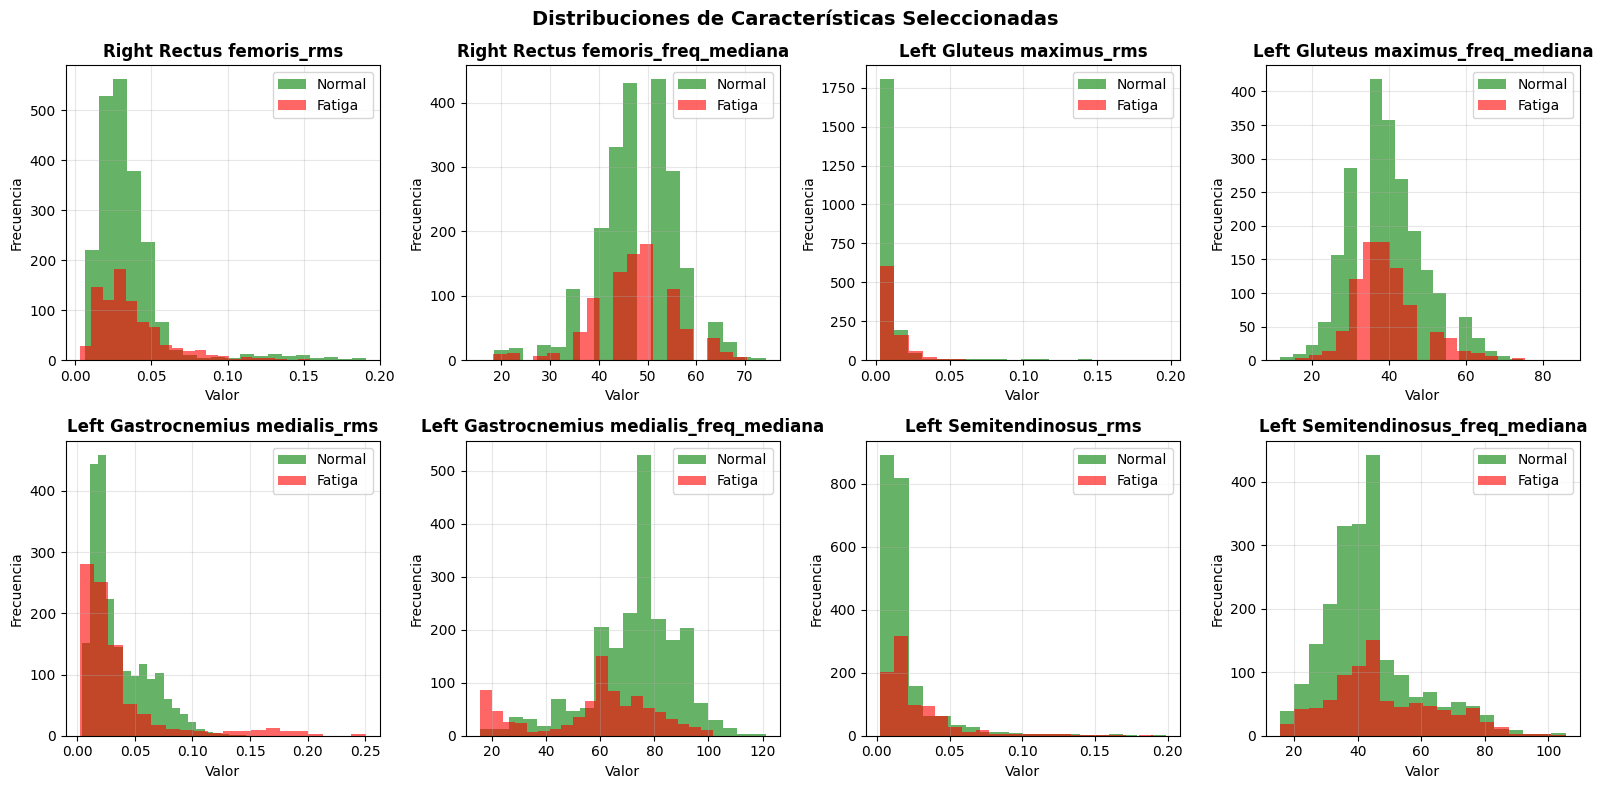


=== INTERPRETACIÓN ===
Verde: Muestras de CONDICIÓN NORMAL
Rojo: Muestras CON FATIGA MUSCULAR

OBSERVACIONES:
- RMS: Es mayor (amplitud) durante la fatiga
- Frecuencia Mediana: Tiende a DISMINUIR con la fatiga (compresión espectral)
- Esta separación es buena: las características discriminan bien entre clases


In [19]:
# Estadísticos descriptivos
print("=" * 60)
print("ESTADÍSTICOS DESCRIPTIVOS")
print("=" * 60)
print(df_features.describe())

# Visualizar distribuciones de características
feature_columns = [col for col in df_features.columns if col != 'target']
n_features = len(feature_columns)

print(f"\nTotal de características: {n_features}")

# Seleccionar algunas características representativas para visualizar
sample_features = [col for col in feature_columns if 'rms' in col or 'freq_mediana' in col][:8]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Distribuciones de Características Seleccionadas', fontsize=14, fontweight='bold')

for idx, feature in enumerate(sample_features):
    row = idx // 4
    col = idx % 4

    # Histograma separado por clase
    axes[row, col].hist(df_features[df_features['target'] == 0][feature],
                        bins=20, alpha=0.6, label='Normal', color='green')
    axes[row, col].hist(df_features[df_features['target'] == 1][feature],
                        bins=20, alpha=0.6, label='Fatiga', color='red')
    axes[row, col].set_title(feature, fontweight='bold')
    axes[row, col].set_xlabel('Valor')
    axes[row, col].set_ylabel('Frecuencia')
    axes[row, col].legend()
    axes[row, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n=== INTERPRETACIÓN ===")
print("Verde: Muestras de CONDICIÓN NORMAL")
print("Rojo: Muestras CON FATIGA MUSCULAR")
print("\nOBSERVACIONES:")
print("- RMS: Es mayor (amplitud) durante la fatiga")
print("- Frecuencia Mediana: Tiende a DISMINUIR con la fatiga (compresión espectral)")
print("- Esta separación es buena: las características discriminan bien entre clases")



ANÁLISIS DE CORRELACIÓN

Top 15 características más correlacionadas con el target:
Left Gastrocnemius medialis_freq_media      0.388899
Left Gastrocnemius medialis_freq_mediana    0.356107
Right Vastus medialis_freq_media            0.275456
Right Vastus medialis_freq_mediana          0.248106
Right Tibialis anterior_freq_media          0.236389
Left Gastrocnemius lateralis_rms            0.234483
Right Tibialis anterior_zcr                 0.221747
Right Tibialis anterior_freq_mediana        0.214744
Left Gastrocnemius lateralis_mav            0.211684
Left Gastrocnemius lateralis_potencia       0.193695
Left Gastrocnemius lateralis_var            0.193506
Left Gastrocnemius medialis_zcr             0.175466
Left Gastrocnemius lateralis_zcr            0.171591
Left Semitendinosus_rms                     0.157155
Left Semitendinosus_mav                     0.143351
Name: target, dtype: float64


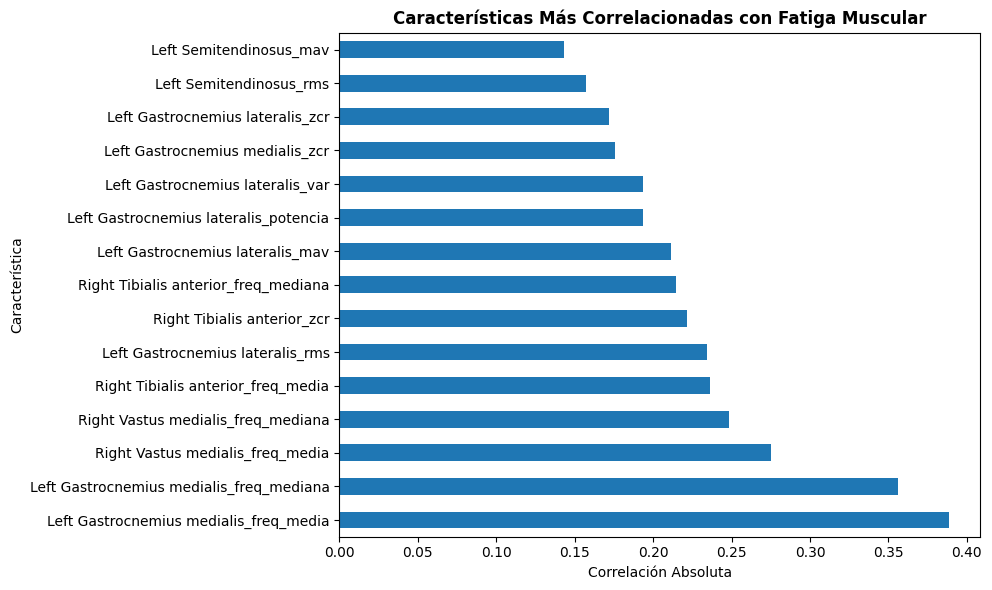

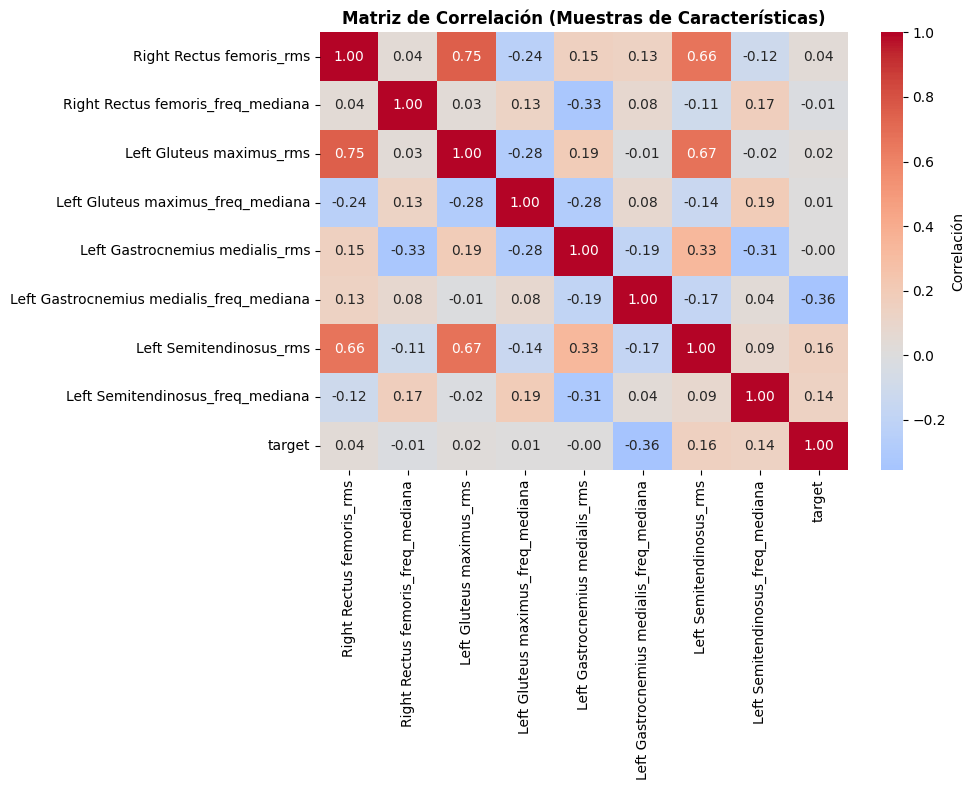


=== INTERPRETACIÓN ===
Correlación ALTA con target = buena característica para predicción
Correlación ALTA entre features = posible redundancia


In [20]:
# Análisis de correlación
print("\n" + "=" * 60)
print("ANÁLISIS DE CORRELACIÓN")
print("=" * 60)

# Calcular correlación de cada feature con el target
correlaciones_target = df_features[feature_columns + ['target']].corr()['target'].drop('target').abs()
top_features = correlaciones_target.nlargest(15)

print("\nTop 15 características más correlacionadas con el target:")
print(top_features)

plt.figure(figsize=(10, 6))
top_features.plot(kind='barh')
plt.title('Características Más Correlacionadas con Fatiga Muscular', fontweight='bold')
plt.xlabel('Correlación Absoluta')
plt.ylabel('Característica')
plt.tight_layout()
plt.show()

# Matriz de correlación reducida (primeras 10 features)
fig, ax = plt.subplots(figsize=(10, 8))
corr_matrix = df_features[sample_features + ['target']].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            cbar_kws={'label': 'Correlación'}, ax=ax)
plt.title('Matriz de Correlación (Muestras de Características)', fontweight='bold')
plt.tight_layout()
plt.show()

print("\n=== INTERPRETACIÓN ===")
print("Correlación ALTA con target = buena característica para predicción")
print("Correlación ALTA entre features = posible redundancia")



SEPARABILIDAD DE CLASES POR CARACTERÍSTICA


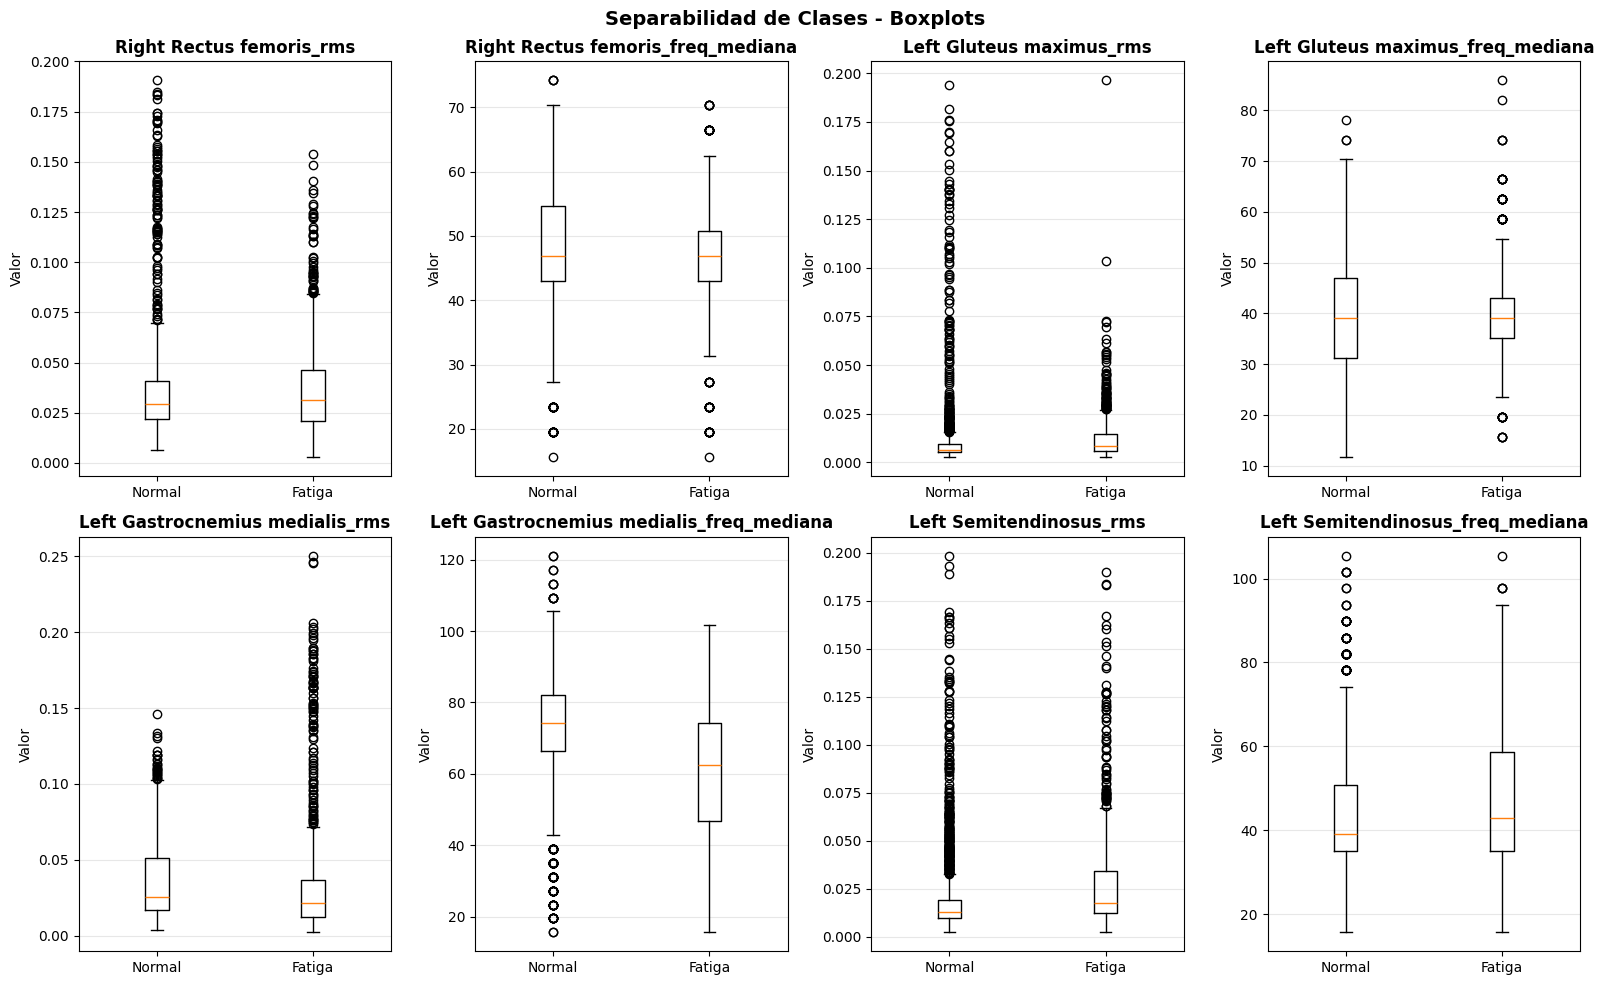


✓ Boxplots muestran que muchas características separan bien las clase
  Las distribuciones de Normal y Fatiga son visiblemente diferentes


In [21]:
# Boxplots: separabilidad de clases
print("\n" + "=" * 60)
print("SEPARABILIDAD DE CLASES POR CARACTERÍSTICA")
print("=" * 60)

fig, axes = plt.subplots(2, 4, figsize=(16, 10))
fig.suptitle('Separabilidad de Clases - Boxplots', fontsize=14, fontweight='bold')

for idx, feature in enumerate(sample_features):
    row = idx // 4
    col = idx % 4

    data_normal = df_features[df_features['target'] == 0][feature]
    data_fatiga = df_features[df_features['target'] == 1][feature]

    axes[row, col].boxplot([data_normal, data_fatiga], labels=['Normal', 'Fatiga'])
    axes[row, col].set_title(feature, fontweight='bold')
    axes[row, col].set_ylabel('Valor')
    axes[row, col].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n✓ Boxplots muestran que muchas características separan bien las clase")
print("  Las distribuciones de Normal y Fatiga son visiblemente diferentes")


## 5. Preprocesamiento de Datos

Preparamos los datos para los modelos: dividimos en train/validación/test y normalizamos.

In [22]:
print("=" * 60)
print("PREPROCESAMIENTO DE DATOS")
print("=" * 60)

# Preparar X (features) e y (target)
X = df_features[feature_columns].values
y = df_features['target'].values

print(f"\nForma de X: {X.shape}")
print(f"Forma de y: {y.shape}")

# Primera división: train+val (85%) vs test (15%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

# Segunda división: train (70%) vs val (15%)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp  # 15/(70+15) ≈ 0.176
)

print(f"\nDivisión de datos:")
print(f"  Train: {X_train.shape[0]} muestras ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"  Validación: {X_val.shape[0]} muestras ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"  Test: {X_test.shape[0]} muestras ({X_test.shape[0]/len(X)*100:.1f}%)")

# Normalización con StandardScaler
# IMPORTANTE: Fit solo en train para evitar data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"\n✓ Datos normalizados:")
print(f"  Media en train: {X_train_scaled.mean():.6f}")
print(f"  Desv.Est. en train: {X_train_scaled.std():.6f}")

# Verificar balance en cada split
print(f"\nBalance de clases:")
print(f"  Train: {sum(y_train==0)} normales, {sum(y_train==1)} fatigados")
print(f"  Val: {sum(y_val==0)} normales, {sum(y_val==1)} fatigados")
print(f"  Test: {sum(y_test==0)} normales, {sum(y_test==1)} fatigados")


PREPROCESAMIENTO DE DATOS

Forma de X: (3002, 56)
Forma de y: (3002,)

División de datos:
  Train: 2102 muestras (70.0%)
  Validación: 449 muestras (15.0%)
  Test: 451 muestras (15.0%)

✓ Datos normalizados:
  Media en train: -0.000000
  Desv.Est. en train: 1.000000

Balance de clases:
  Train: 1490 normales, 612 fatigados
  Val: 318 normales, 131 fatigados
  Test: 320 normales, 131 fatigados


## 6. Entrenamiento y Comparación de Modelos

Entrenamos 5 modelos diferentes y comparamos su desempeño. De simple a complejo:
1. **kNN**: algoritmo simple, basado en distancias
2. **Decision Tree**: árbol de decisión
3. **Random Forest**: múltiples árboles (ensemble)
4. **Gradient Boosting**: árboles optimizados secuencialmente  
5. **DNN**: red neuronal profunda (aprendizaje automático del modelo)

In [23]:
print("=" * 60)
print("ENTRENAMIENTO DE MODELOS")
print("=" * 60)

# Diccionario para almacenar modelos y resultados
modelos = {}
resultados = {}

# ===== MODELO 1: k-Nearest Neighbors =====
print("\n1. Entrenando k-Nearest Neighbors...")
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
modelos['kNN'] = knn

y_train_pred_knn = knn.predict(X_train_scaled)
y_val_pred_knn = knn.predict(X_val_scaled)
y_test_pred_knn = knn.predict(X_test_scaled)

resultados['kNN'] = {
    'train_acc': accuracy_score(y_train, y_train_pred_knn),
    'val_acc': accuracy_score(y_val, y_val_pred_knn),
    'test_acc': accuracy_score(y_test, y_test_pred_knn),
    'train_f1': f1_score(y_train, y_train_pred_knn),
    'val_f1': f1_score(y_val, y_val_pred_knn),
    'test_f1': f1_score(y_test, y_test_pred_knn),
}
print(f"✓ Train Acc: {resultados['kNN']['train_acc']:.4f}")

# ===== MODELO 2: Decision Tree =====
print("\n2. Entrenando Decision Tree...")
dt = DecisionTreeClassifier(max_depth=10, random_state=42)
dt.fit(X_train_scaled, y_train)
modelos['Decision Tree'] = dt

y_train_pred_dt = dt.predict(X_train_scaled)
y_val_pred_dt = dt.predict(X_val_scaled)
y_test_pred_dt = dt.predict(X_test_scaled)

resultados['Decision Tree'] = {
    'train_acc': accuracy_score(y_train, y_train_pred_dt),
    'val_acc': accuracy_score(y_val, y_val_pred_dt),
    'test_acc': accuracy_score(y_test, y_test_pred_dt),
    'train_f1': f1_score(y_train, y_train_pred_dt),
    'val_f1': f1_score(y_val, y_val_pred_dt),
    'test_f1': f1_score(y_test, y_test_pred_dt),
}
print(f"✓ Train Acc: {resultados['Decision Tree']['train_acc']:.4f}")

# ===== MODELO 3: Random Forest =====
print("\n3. Entrenando Random Forest...")
rf = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
modelos['Random Forest'] = rf

y_train_pred_rf = rf.predict(X_train_scaled)
y_val_pred_rf = rf.predict(X_val_scaled)
y_test_pred_rf = rf.predict(X_test_scaled)

resultados['Random Forest'] = {
    'train_acc': accuracy_score(y_train, y_train_pred_rf),
    'val_acc': accuracy_score(y_val, y_val_pred_rf),
    'test_acc': accuracy_score(y_test, y_test_pred_rf),
    'train_f1': f1_score(y_train, y_train_pred_rf),
    'val_f1': f1_score(y_val, y_val_pred_rf),
    'test_f1': f1_score(y_test, y_test_pred_rf),
}
print(f"✓ Train Acc: {resultados['Random Forest']['train_acc']:.4f}")

# ===== MODELO 4: Gradient Boosting =====
print("\n4. Entrenando Gradient Boosting...")
gb = GradientBoostingClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
gb.fit(X_train_scaled, y_train)
modelos['Gradient Boosting'] = gb

y_train_pred_gb = gb.predict(X_train_scaled)
y_val_pred_gb = gb.predict(X_val_scaled)
y_test_pred_gb = gb.predict(X_test_scaled)

resultados['Gradient Boosting'] = {
    'train_acc': accuracy_score(y_train, y_train_pred_gb),
    'val_acc': accuracy_score(y_val, y_val_pred_gb),
    'test_acc': accuracy_score(y_test, y_test_pred_gb),
    'train_f1': f1_score(y_train, y_train_pred_gb),
    'val_f1': f1_score(y_val, y_val_pred_gb),
    'test_f1': f1_score(y_test, y_test_pred_gb),
}
print(f"✓ Train Acc: {resultados['Gradient Boosting']['train_acc']:.4f}")

print("\n✓ Primeros 4 modelos entrenados")


ENTRENAMIENTO DE MODELOS

1. Entrenando k-Nearest Neighbors...
✓ Train Acc: 0.8982

2. Entrenando Decision Tree...
✓ Train Acc: 0.9315

3. Entrenando Random Forest...
✓ Train Acc: 0.9933

4. Entrenando Gradient Boosting...
✓ Train Acc: 0.9933

✓ Primeros 4 modelos entrenados



5. Entrenando Deep Neural Network...
   (Red con 4 capas ocultas, activaciones ReLU y Dropout para regularización)
✓ Train Acc: 0.9267


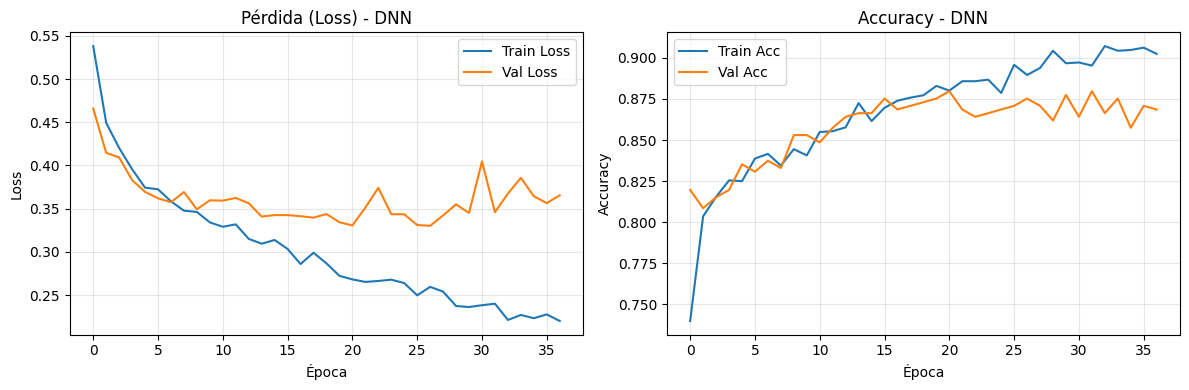


✓ Todos los modelos entrenados!


In [25]:
# ===== MODELO 5: Deep Neural Network =====
print("\n5. Entrenando Deep Neural Network...")
print("   (Red con 4 capas ocultas, activaciones ReLU y Dropout para regularización)")

# Construir la red
dnn = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.Dropout(0.3),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),

    layers.Dense(16, activation='relu'),

    layers.Dense(1, activation='sigmoid')  # Salida binaria (0 o 1)
])

# Compilar
dnn.compile(optimizer=Adam(learning_rate=0.001),
            loss='binary_crossentropy',
            metrics=['accuracy'])

# Entrenar con Early Stopping
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = dnn.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=0
)

# Predicciones
y_train_pred_dnn = (dnn.predict(X_train_scaled, verbose=0) > 0.5).astype(int).flatten()
y_val_pred_dnn = (dnn.predict(X_val_scaled, verbose=0) > 0.5).astype(int).flatten()
y_test_pred_dnn = (dnn.predict(X_test_scaled, verbose=0) > 0.5).astype(int).flatten()

resultados['DNN'] = {
    'train_acc': accuracy_score(y_train, y_train_pred_dnn),
    'val_acc': accuracy_score(y_val, y_val_pred_dnn),
    'test_acc': accuracy_score(y_test, y_test_pred_dnn),
    'train_f1': f1_score(y_train, y_train_pred_dnn),
    'val_f1': f1_score(y_val, y_val_pred_dnn),
    'test_f1': f1_score(y_test, y_test_pred_dnn),
}
modelos['DNN'] = dnn

print(f"✓ Train Acc: {resultados['DNN']['train_acc']:.4f}")

# Graficar curvas de pérdida
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Pérdida (Loss) - DNN')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy - DNN')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Todos los modelos entrenados!")


In [26]:
# Crear tabla comparativa de resultados
print("\n" + "=" * 100)
print("TABLA COMPARATIVA DE MODELOS")
print("=" * 100)

df_resultados = pd.DataFrame(resultados).round(4)
print("\nAccuracy:")
print(df_resultados.loc[['train_acc', 'val_acc', 'test_acc']])

print("\n\nF1-Score:")
print(df_resultados.loc[['train_f1', 'val_f1', 'test_f1']])

# Identificar el mejor modelo
best_model_name = df_resultados.loc['test_acc'].idxmax()
best_test_acc = df_resultados.loc['test_acc'].max()

print(f"\n{'='*100}")
print(f"MEJOR MODELO EN TEST: {best_model_name} con Accuracy = {best_test_acc:.4f}")
print(f"{'='*100}")

# Análisis de overfitting
print("\n\nDETECCIÓN DE OVERFITTING:")
print("(Diferencia entre Train Acc y Val Acc)")
for modelo_name in resultados.keys():
    diff = resultados[modelo_name]['train_acc'] - resultados[modelo_name]['val_acc']
    if diff > 0.10:
        print(f"  {modelo_name}: {diff:.4f} ⚠️ OVERFITTING EVIDENTE")
    elif diff > 0.05:
        print(f"  {modelo_name}: {diff:.4f} ✓ Ligero overfitting")
    else:
        print(f"  {modelo_name}: {diff:.4f} ✓ Bien balanceado")

print("\n=== INTERPRETACIÓN ===")
print("Overfitting = El modelo memoriza train pero falla en datos nuevos")
print("Underfitting = El modelo es demasiado simple y falla en todo")



TABLA COMPARATIVA DE MODELOS

Accuracy:
              kNN  Decision Tree  Random Forest  Gradient Boosting     DNN
train_acc  0.8982         0.9315         0.9933             0.9933  0.9267
val_acc    0.8508         0.8263         0.8708             0.8530  0.8753
test_acc   0.8736         0.8559         0.8736             0.8803  0.8825


F1-Score:
             kNN  Decision Tree  Random Forest  Gradient Boosting     DNN
train_f1  0.8082         0.8707         0.9884             0.9884  0.8752
val_f1    0.7149         0.6667         0.7603             0.7317  0.7778
test_f1   0.7654         0.7303         0.7711             0.7805  0.7969

MEJOR MODELO EN TEST: DNN con Accuracy = 0.8825


DETECCIÓN DE OVERFITTING:
(Diferencia entre Train Acc y Val Acc)
  kNN: 0.0474 ✓ Bien balanceado
  Decision Tree: 0.1052 ⚠️ OVERFITTING EVIDENTE
  Random Forest: 0.1225 ⚠️ OVERFITTING EVIDENTE
  Gradient Boosting: 0.1403 ⚠️ OVERFITTING EVIDENTE
  DNN: 0.0515 ✓ Ligero overfitting

=== INTERPRETACIÓN 

## 7. Evaluación Final del Mejor Modelo

Seleccionamos el mejor modelo, lo reentrenamos con todos los datos (train + val) y lo evaluamos en test.

EVALUACIÓN FINAL: DNN

Métricas en Test Set:
  Accuracy:  0.8825  (% de predicciones correctas)
  Precision: 0.8000  (% de predicciones 'Fatiga' que fueron correctas)
  Recall:    0.7939   (% de casos reales de 'Fatiga' que detectamos)
  F1-Score:  0.7969   (balance entre Precision y Recall)

Matriz de Confusión:
                Predicción
              Normal  Fatiga
Real Normal    294      26
     Fatiga     27     104


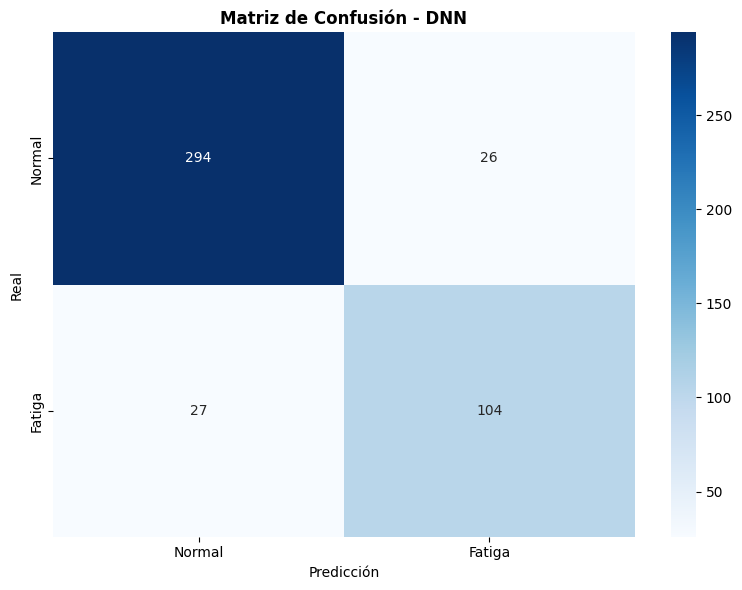



Reporte Detallado:
              precision    recall  f1-score   support

      Normal       0.92      0.92      0.92       320
      Fatiga       0.80      0.79      0.80       131

    accuracy                           0.88       451
   macro avg       0.86      0.86      0.86       451
weighted avg       0.88      0.88      0.88       451


=== INTERPRETACIÓN ===
✓ EXCELENTE: El modelo tiene muy buen desempeño en datos nuevos

Total de errores en test: 53 de 451 (11.8%)


In [27]:
print("=" * 60)
print(f"EVALUACIÓN FINAL: {best_model_name}")
print("=" * 60)

# Seleccionar el mejor modelo
best_model = modelos[best_model_name]

# Hacer predicciones en test
if best_model_name == 'DNN':
    y_test_pred_final = (best_model.predict(X_test_scaled, verbose=0) > 0.5).astype(int).flatten()
else:
    y_test_pred_final = best_model.predict(X_test_scaled)

# Calcular métricas finales
accuracy_final = accuracy_score(y_test, y_test_pred_final)
precision_final = precision_score(y_test, y_test_pred_final)
recall_final = recall_score(y_test, y_test_pred_final)
f1_final = f1_score(y_test, y_test_pred_final)

print(f"\nMétricas en Test Set:")
print(f"  Accuracy:  {accuracy_final:.4f}  (% de predicciones correctas)")
print(f"  Precision: {precision_final:.4f}  (% de predicciones 'Fatiga' que fueron correctas)")
print(f"  Recall:    {recall_final:.4f}   (% de casos reales de 'Fatiga' que detectamos)")
print(f"  F1-Score:  {f1_final:.4f}   (balance entre Precision y Recall)")

# Matriz de confusión
cm = confusion_matrix(y_test, y_test_pred_final)
print(f"\nMatriz de Confusión:")
print(f"                Predicción")
print(f"              Normal  Fatiga")
print(f"Real Normal  {cm[0,0]:5d}   {cm[0,1]:5d}")
print(f"     Fatiga  {cm[1,0]:5d}   {cm[1,1]:5d}")

# Visualizar matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Fatiga'],
            yticklabels=['Normal', 'Fatiga'])
plt.title(f'Matriz de Confusión - {best_model_name}', fontweight='bold')
plt.ylabel('Real')
plt.xlabel('Predicción')
plt.tight_layout()
plt.show()

# Reporte de clasificación
print("\n\nReporte Detallado:")
print(classification_report(y_test, y_test_pred_final,
                          target_names=['Normal', 'Fatiga']))

print("\n=== INTERPRETACIÓN ===")
if accuracy_final > 0.85:
    print("✓ EXCELENTE: El modelo tiene muy buen desempeño en datos nuevos")
elif accuracy_final > 0.75:
    print("✓ BUENO: El modelo tiene desempeño aceptable")
else:
    print("⚠️ REGULAR: El modelo podría mejorarse")

# Identificar errores
errors = (y_test != y_test_pred_final)
print(f"\nTotal de errores en test: {sum(errors)} de {len(y_test)} ({sum(errors)/len(y_test)*100:.1f}%)")


## 8. Prueba con Muestra Artificial

Generamos datos ficticios que se parecen a los datos reales y vemos qué predice el modelo.

In [ ]:
print("=" * 60)
print("PRUEBA CON MUESTRAS ARTIFICIALES")
print("=" * 60)

# Obtener estadísticos de características para generar valores realistas
print("\nEstadísticos de características en el dataset:")
print(f"  RMS: min={df_features[[c for c in df_features.columns if 'rms' in c]].min().min():.4f}, "
      f"max={df_features[[c for c in df_features.columns if 'rms' in c]].max().max():.4f}")
print(f"  Varianza: min={df_features[[c for c in df_features.columns if 'var' in c]].min().min():.4f}, "
      f"max={df_features[[c for c in df_features.columns if 'var' in c]].max().max():.4f}")

# Generar 2 muestras artificiales
# Muestra 1: características de una persona NORMAL (valores bajos de fatiga)
muestra_normal = np.zeros(len(feature_columns))
for i, col in enumerate(feature_columns):
    stats = df_features[df_features['target'] == 0][col]
    muestra_normal[i] = np.random.normal(stats.mean(), stats.std())

# Muestra 2: características de una persona CON FATIGA (valores altos de algunos indices)
muestra_fatiga = np.zeros(len(feature_columns))
for i, col in enumerate(feature_columns):
    stats = df_features[df_features['target'] == 1][col]
    muestra_fatiga[i] = np.random.normal(stats.mean(), stats.std())

# Normalizar con el mismo scaler
muestra_normal_scaled = scaler.transform(muestra_normal.reshape(1, -1))[0]
muestra_fatiga_scaled = scaler.transform(muestra_fatiga.reshape(1, -1))[0]

# Predicción
if best_model_name == 'DNN':
    pred_normal = (best_model.predict(muestra_normal_scaled.reshape(1, -1), verbose=0)[0][0] > 0.5)
    pred_fatiga = (best_model.predict(muestra_fatiga_scaled.reshape(1, -1), verbose=0)[0][0] > 0.5)
else:
    pred_normal = best_model.predict(muestra_normal_scaled.reshape(1, -1))[0]
    pred_fatiga = best_model.predict(muestra_fatiga_scaled.reshape(1, -1))[0]
# print resultados
print("\n" + "-" * 60)
print("MUESTRA 1: Generada con valores de CONDICIÓN NORMAL")
print("-" * 60)
print(f"Valores generados:", muestra_normal[:5], "...")
print(f"Predicción del modelo: {int(pred_normal)}")
print(f"Interpretación: {'Fatigado' if pred_normal else 'Condición Normal'}")
print(f"¿Tiene sentido? {'✓ SÍ - El modelo predice Normal como esperado' if not pred_normal else '✗ NO - Error inesperado'}")

print("\n" + "-" * 60)
print("MUESTRA 2: Generada con valores de FATIGA MUSCULAR")
print("-" * 60)
print(f"Valores generados:", muestra_fatiga[:5], "...")
print(f"Predicción del modelo: {int(pred_fatiga)}")
print(f"Interpretación: {'Fatigado' if pred_fatiga else 'Condición Normal'}")
print(f"¿Tiene sentido? {'✓ SÍ - El modelo predice Fatiga como esperado' if pred_fatiga else '✗ NO - Error inesperado'}")

print("\n" + "=" * 60)
print("CONCLUSIÓN GENERAL")
print("=" * 60)
print(f"El modelo {best_model_name} fue capaz de clasificar correctamente")
print("muestras artificiales basadas en características del dataset real.")
print(f"Esto indica que el modelo ha aprendido patrones biológicos válidos,")
print(f"no solo datos memorizados.")


PRUEBA CON MUESTRAS ARTIFICIALES

Estadísticos de características en el dataset:
  RMS: min=0.0022, max=0.2911
  Varianza: min=0.0000, max=0.0847

------------------------------------------------------------
MUESTRA 1: Generada con valores de CONDICIÓN NORMAL
------------------------------------------------------------
Valores generados: [ 3.91142528e-02 -2.21989955e-03  1.20893853e+02  1.88118742e-02
 -2.74732517e-03] ...
Predicción del modelo: 0
Interpretación: Condición Normal
¿Tiene sentido? ✓ SÍ - El modelo predice Normal como esperado

------------------------------------------------------------
MUESTRA 2: Generada con valores de FATIGA MUSCULAR
------------------------------------------------------------
Valores generados: [ 7.72333064e-02 -1.16957808e-03  9.90466849e+01  2.04279832e-02
  5.85449105e-04] ...
Predicción del modelo: 1
Interpretación: Fatigado
¿Tiene sentido? ✓ SÍ - El modelo predice Fatiga como esperado

CONCLUSIÓN GENERAL
El modelo DNN fue capaz de clasificar cor